In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cv2
import os
import glob
from Icefin.analyze_videos import*
from socket import gethostname
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os, sys
sys.path.append(os.getcwd())
os.chdir("../..")
savedir = os.path.join(os.getcwd(),"DATA")
path = os.getcwd()
path = os.path.join(path,"DATA/SIOS21/")
    
path_v = path+"MARS_ICE02_034/"
netcdf_path = os.path.join(path_v, "netcdf_frazil_data")

ds_ctd = xr.open_dataset(path+"/Ant2021/Ant2021CTDdata/SBE19p_Ant2021_FbestALCT_cast2_3_SC.nc", engine="netcdf4")
ds_fic = xr.open_dataset(os.path.join(netcdf_path, "MARS_ICE02_034_1_box_4_thresh_40_stats_all.nc"), engine="netcdf4")

In [2]:
ds_fic.bulk_concentration.data

array([3.35039739e-05, 8.93626089e-08, 5.72097299e-08, 1.40014931e-07,
       2.67452088e-07, 7.26046734e-07, 3.36407930e-06, 7.21291018e-07])

In [3]:
path+"/Ant2021/Ant2021CTDdata/SBE19p_Ant2021_FbestALCT_cast2_3_SC.nc"

'/home/nina/pCloudDrive/DATA/SIOS21//Ant2021/Ant2021CTDdata/SBE19p_Ant2021_FbestALCT_cast2_3_SC.nc'

In [4]:
# choose the second cast on 3 Nov to analyze, because it's closest to the Icefin dives
start_time = pd.to_datetime('2021-11-03 01:12:00',
               format='%Y-%m-%d %H:%M:%S')
mid_time = pd.to_datetime('2021-11-03 01:23:00',
               format='%Y-%m-%d %H:%M:%S')
end_time = pd.to_datetime('2021-11-03 01:39:00',
               format='%Y-%m-%d %H:%M:%S')
time_cast = start_time

# select the upcast data
upcast = ds_ctd.sel(time=slice(mid_time, end_time))
upcast

<xarray.Dataset> Size: 307kB
Dimensions:        (time: 3841)
Coordinates:
  * time           (time) datetime64[ns] 31kB 2021-11-03T01:23:00 ... 2021-11...
    depth          (time) float64 31kB ...
Data variables:
    con            (time) float64 31kB ...
    SP             (time) float64 31kB ...
    Temperature    (time) float64 31kB ...
    Pressure_dbar  (time) float64 31kB ...
    fp             (time) float64 31kB ...
    rho            (time) float64 31kB ...
    SC             (time) float64 31kB ...
    SC_potential   (time) float64 31kB ...

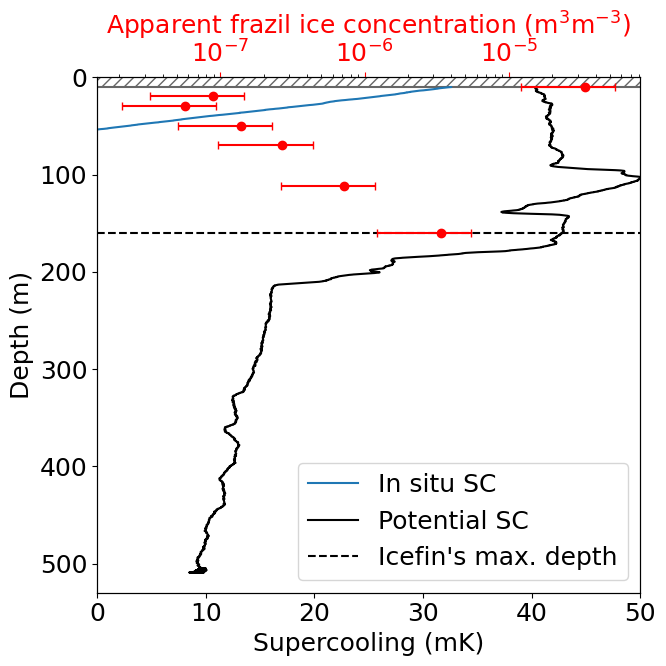

In [6]:
plt.rcParams.update({'font.size': 18})

fig, ax = plt.subplots(figsize=(7,7))

# Select only the range 10–530 m and drop the rest
subset = upcast.where((upcast.depth >= 10) & (upcast.depth <= 530), drop=True)

# Sort so that depth decreases (typical "upcast" plotting order)
up = subset.sortby('depth', ascending=False)

line2, = ax.plot(up.SC, up.depth, label="In situ SC")
line1, = ax.plot(up.SC_potential, up.depth, color="black", label="Potential SC")

ax.set_xlim([0, 50])
ax.invert_yaxis()
ax.set_xlabel("Supercooling (mK)")
default_blue = line1.get_color()
ax.xaxis.label.set_color(default_blue)
ax.tick_params(axis='x', colors=default_blue)

# Create a twin axis
ax_twin = ax.twiny()

# --- Hatch the top 10 m (0–10 m) ---
ax.axhspan(
    0, 10,
    facecolor="none",
    edgecolor="0.4",
    hatch="///",
    linewidth=0.0,
    zorder=0
)

# --- Line at the base of the hatched region (10 m) ---
ax.axhline(
    y=10,
    color="0.4",
    linewidth=1.5,
    zorder=1
)

# --- Compute relative x error (63.7%) for frazil concentration ---
rel_err = 0.637  # followed from frazil_size_and_concentration_uncertainty.ipynb
x_vals = np.asarray(ds_fic.bulk_concentration[:-1])
y_vals = np.asarray(ds_fic.depth[:-1])

# For log scale, zero/negative x or NaNs will break plotting. Mask them out for error bars.
valid = np.isfinite(x_vals) & np.isfinite(y_vals) & (x_vals > 0)

xerr = np.zeros_like(x_vals, dtype=float)
xerr[valid] = rel_err * x_vals[valid]

# Draw the scatter points (all points, even those not valid for error bars)
scatter = ax_twin.scatter(x_vals, y_vals, color="red", zorder=3, label="Frazil concentration")

# Add horizontal error bars only where valid
ax_twin.errorbar(
    x_vals[valid], y_vals[valid],
    xerr=xerr[valid],
    yerr=None,               # no vertical error specified
    fmt='none',              # draw only bars (no markers)
    ecolor='red',
    elinewidth=1.5,
    capsize=3,
    zorder=2
)

# Other decorations
ax.axhline(y=(ds_fic.depth).max(), color="black", linestyle="dashed", label="Icefin's max. depth")
ax_twin.set_xscale("log")
ax_twin.set_xlabel(r"Apparent frazil ice concentration (m$^3$m$^{-3}$)")
ax_twin.xaxis.label.set_color("red")
ax_twin.tick_params(axis='x', colors="red")
ax.legend()
ax.set_ylabel("Depth (m)")
plt.tight_layout()
plt.ylim([530, 0])
plt.savefig(savedir+"FIC_SC"+".png", bbox_inches="tight")